# Projet Final — Partie 1 : Données Tabulaires
## Prédiction de Maladies Cardiovasculaires

**Dataset :** Cardiovascular Disease Dataset (Kaggle — Svetlana Ulianova)  
**Tâche :** Classification binaire — présence ou absence de maladie cardiovasculaire  
**Modèles :** MLP (fait maison) · Logistic Regression · Random Forest · XGBoost  

---
## Pipeline
1. Installation & chargement Kaggle
2. Chargement & exploration des données
3. Preprocessing
4. Séparation Train / Test
5. Modèle fait maison — MLP TensorFlow
6. Modèles de comparaison (LR, RF, XGBoost)
7. Étude comparative
8. Sauvegarde

---
## 0. Installation des dépendances

In [1]:
# installation tous les prérequis
%pip install tensorflow scikit-learn pandas numpy matplotlib seaborn kaggle xgboost -q

Note: you may need to restart the kernel to use updated packages.


---
## 1. Configuration Kaggle & Téléchargement du Dataset

### Prérequis : récupérer sa clé API Kaggle
1. aller sur https://www.kaggle.com → Photo de profil → **Settings**
2. Section **API** → cliquer **"Create New Token"**
3. Un fichier `kaggle.json` se télécharge avec ce contenu :
```json
{"username": "ton_username", "key": "ta_clé_api"}
```
4. **Renseigne ton username et ta clé** dans la cellule ci-dessous

In [2]:
import os, json

KAGGLE_USERNAME = "godglorykondo"   
KAGGLE_KEY      = "KGAT_90983d40329c18d31c05ca2c867d496e"    

# Création automatique du fichier ~/.kaggle/kaggle.json
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_config = {'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}
kaggle_path = os.path.join(kaggle_dir, 'kaggle.json')

with open(kaggle_path, 'w') as f:
    json.dump(kaggle_config, f)

# Permissions requises par Kaggle CLI (lecture seule pour le propriétaire)
os.chmod(kaggle_path, 0o600)

print(f"Fichier kaggle.json créé : {kaggle_path}")

Fichier kaggle.json créé : C:\Users\oyeos/.kaggle\kaggle.json


In [3]:
# Téléchargement du dataset depuis Kaggle
# Format : kaggle datasets download -d <auteur>/<nom-dataset>
!kaggle datasets download -d sulianova/cardiovascular-disease-dataset --unzip -p ./data/

# Vérification
import os
files = os.listdir('./data/')
print("Fichiers téléchargés :", files)

Fichiers téléchargés : ['cardio_train.csv', 'sample']


'kaggle' n'est pas reconnu en tant que commande interne
ou externe, un programme ex‚cutable ou un fichier de commandes.


---
## 2. Imports

In [4]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# --- Sklearn ---
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, auc
)

# --- XGBoost ---
from xgboost import XGBClassifier

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
# Dense            : couche entièrement connectée
# BatchNormalization : normalise les activations → convergence plus stable
# Dropout          : régularisation anti-overfitting
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
# Adam             : optimiseur adaptatif standard
from tensorflow.keras.optimizers import Adam
# EarlyStopping    : arrête si val_loss stagne
# ReduceLROnPlateau: réduit le lr si stagnation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

---
## 3. Chargement & Exploration des Données

In [5]:
# Chargement — séparateur ';' (format du fichier Kaggle)
df = pd.read_csv('./data/cardio_train.csv', sep=';')

print(f"Dimensions  : {df.shape}  ({df.shape[0]:,} patients × {df.shape[1]} colonnes)")
print(f"\nDescription des colonnes :")
print("-" * 55)

descriptions = {
    'id'        : 'Identifiant unique patient',
    'age'       : 'Âge en jours (à convertir en années)',
    'gender'    : 'Genre : 1=femme, 2=homme',
    'height'    : 'Taille en cm',
    'weight'    : 'Poids en kg',
    'ap_hi'     : 'Pression artérielle systolique (mmHg)',
    'ap_lo'     : 'Pression artérielle diastolique (mmHg)',
    'cholesterol': 'Cholestérol : 1=normal, 2=élevé, 3=très élevé',
    'gluc'      : 'Glycémie : 1=normale, 2=élevée, 3=très élevée',
    'smoke'     : 'Tabagisme : 0=non, 1=oui',
    'alco'      : 'Alcool : 0=non, 1=oui',
    'active'    : 'Activité physique : 0=non, 1=oui',
    'cardio'    : 'CIBLE : 0=sain, 1=maladie cardiovasculaire'
}

for col, desc in descriptions.items():
    if col in df.columns:
        print(f"  {col:<15} : {desc}")

display(df.head(5))

Dimensions  : (70000, 14)  (70,000 patients × 14 colonnes)

Description des colonnes :
-------------------------------------------------------
  id              : Identifiant unique patient
  age             : Âge en jours (à convertir en années)
  gender          : Genre : 1=femme, 2=homme
  height          : Taille en cm
  weight          : Poids en kg
  ap_hi           : Pression artérielle systolique (mmHg)
  ap_lo           : Pression artérielle diastolique (mmHg)
  cholesterol     : Cholestérol : 1=normal, 2=élevé, 3=très élevé
  gluc            : Glycémie : 1=normale, 2=élevée, 3=très élevée
  smoke           : Tabagisme : 0=non, 1=oui
  alco            : Alcool : 0=non, 1=oui
  active          : Activité physique : 0=non, 1=oui
  cardio          : CIBLE : 0=sain, 1=maladie cardiovasculaire


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,52
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,48


In [6]:
print("=== Informations générales ===")
print(df.info())
print("\n=== Valeurs manquantes ===")
print(df.isnull().sum())
print(f"\n=== Distribution de la cible ===")
print(df['cardio'].value_counts())
print(f"Équilibre   : {df['cardio'].value_counts(normalize=True).mul(100).round(1).to_string()}%")

=== Informations générales ===
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
 13  age_years    70000 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 7.5 MB
None

=== Valeurs manquantes ===
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo        

In [7]:
# Statistiques descriptives
display(df.describe().round(2))

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.0,70000.0,70000.00
mean,49972.42,19468.87,1.35,164.36,74.21,128.82,96.63,1.37,1.23,0.09,0.05,0.8,0.5,53.34
std,28851.30,2467.25,0.48,8.21,14.40,154.01,188.47,0.68,0.57,0.28,0.23,0.4,0.5,6.77
min,0.00,10798.00,1.00,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.0,0.0,30.00
25%,25006.75,17664.00,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0,48.00
50%,50001.50,19703.00,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0,54.00
75%,74889.25,21327.00,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.0,58.00
max,99999.00,23713.00,2.00,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.0,1.0,65.00


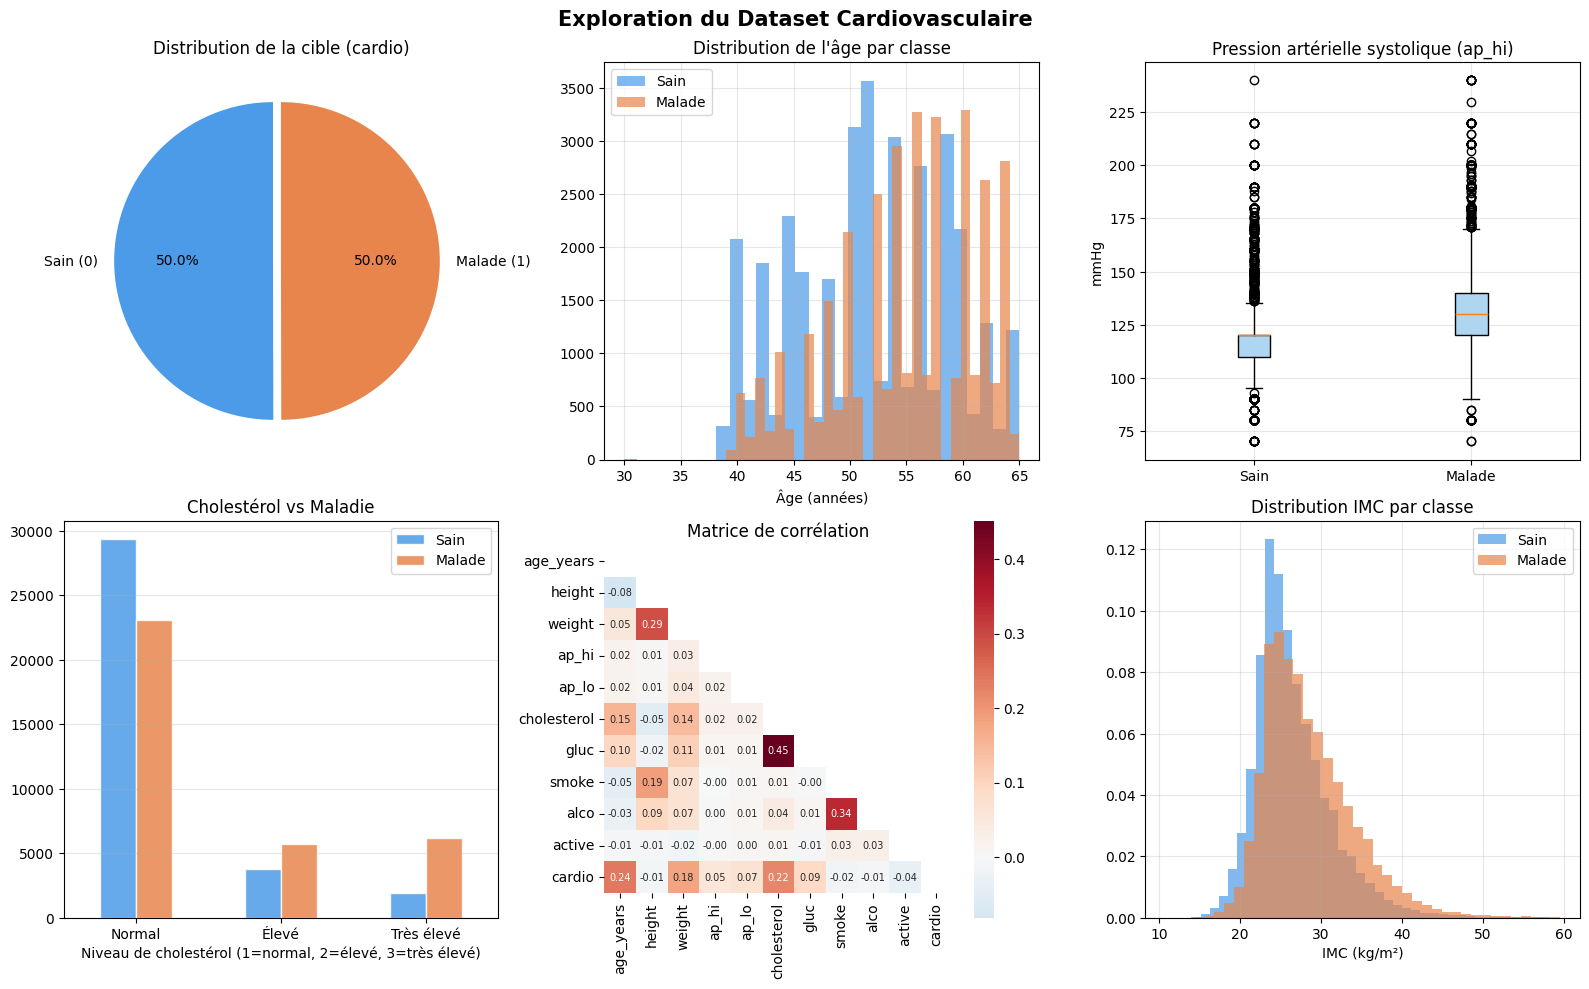

In [8]:
# ── Visualisation exploratoire ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploration du Dataset Cardiovasculaire', fontsize=15, fontweight='bold')

# 1. Distribution de la cible
counts = df['cardio'].value_counts()
axes[0,0].pie(counts, labels=['Sain (0)', 'Malade (1)'],
              autopct='%1.1f%%', colors=['#4C9BE8', '#E8854C'],
              startangle=90, explode=(0.05, 0))
axes[0,0].set_title('Distribution de la cible (cardio)')

# 2. Distribution de l'âge
df['age_years'] = (df['age'] / 365).round(0).astype(int)
axes[0,1].hist(df[df['cardio']==0]['age_years'], bins=30, alpha=0.7,
               color='#4C9BE8', label='Sain')
axes[0,1].hist(df[df['cardio']==1]['age_years'], bins=30, alpha=0.7,
               color='#E8854C', label='Malade')
axes[0,1].set_title('Distribution de l\'âge par classe')
axes[0,1].set_xlabel('Âge (années)')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 3. Pression artérielle systolique
df_clean = df[(df['ap_hi'] > 60) & (df['ap_hi'] < 250)]
axes[0,2].boxplot(
    [df_clean[df_clean['cardio']==0]['ap_hi'],
     df_clean[df_clean['cardio']==1]['ap_hi']],
    labels=['Sain', 'Malade'],
    patch_artist=True,
    boxprops=dict(facecolor='#AED6F1')
)
axes[0,2].set_title('Pression artérielle systolique (ap_hi)')
axes[0,2].set_ylabel('mmHg')
axes[0,2].grid(alpha=0.3)

# 4. Cholestérol vs cardio
chol_cardio = df.groupby(['cholesterol','cardio']).size().unstack()
chol_cardio.plot(kind='bar', ax=axes[1,0], color=['#4C9BE8','#E8854C'],
                 alpha=0.85, edgecolor='white')
axes[1,0].set_title('Cholestérol vs Maladie')
axes[1,0].set_xlabel('Niveau de cholestérol (1=normal, 2=élevé, 3=très élevé)')
axes[1,0].set_xticklabels(['Normal', 'Élevé', 'Très élevé'], rotation=0)
axes[1,0].legend(['Sain', 'Malade'])
axes[1,0].grid(alpha=0.3, axis='y')

# 5. Corrélations
numeric_cols = ['age_years','height','weight','ap_hi','ap_lo',
                'cholesterol','gluc','smoke','alco','active','cardio']
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[1,1], cmap='RdBu_r',
            center=0, annot=True, fmt='.2f', square=True,
            annot_kws={'size': 7})
axes[1,1].set_title('Matrice de corrélation')

# 6. BMI distribution
df['bmi'] = df['weight'] / ((df['height']/100)**2)
df_bmi = df[(df['bmi'] > 10) & (df['bmi'] < 60)]
axes[1,2].hist(df_bmi[df_bmi['cardio']==0]['bmi'], bins=40, alpha=0.7,
               color='#4C9BE8', label='Sain', density=True)
axes[1,2].hist(df_bmi[df_bmi['cardio']==1]['bmi'], bins=40, alpha=0.7,
               color='#E8854C', label='Malade', density=True)
axes[1,2].set_title('Distribution IMC par classe')
axes[1,2].set_xlabel('IMC (kg/m²)')
axes[1,2].legend()
axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('exploration_cardiovasculaire.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Preprocessing

| Étape | Opération | Justification |
|-------|-----------|---------------|
| **Conversion âge** | jours → années | Plus interprétable, même échelle |
| **Feature Engineering** | Ajout IMC, pression pulse | Variables médicalement pertinentes |
| **Suppression outliers** | Valeurs aberrantes tensionnelles | Erreurs de saisie médicale |
| **Suppression id** | Colonne non informative | Évite le surapprentissage |
| **StandardScaler** | µ=0, σ=1 | Obligatoire pour MLP et LR |

In [9]:
df_processed = df.copy()

# ── 1. Conversion âge : jours → années ───────────────────────────────────────
df_processed['age'] = (df_processed['age'] / 365).round(0).astype(int)

# ── 2. Feature Engineering ────────────────────────────────────────────────────
# IMC (Indice de Masse Corporelle) : facteur de risque cardiovasculaire reconnu
df_processed['bmi'] = (df_processed['weight'] /
                       (df_processed['height'] / 100) ** 2).round(2)

# Pression pulsée = systolique - diastolique : indicateur de rigidité artérielle
df_processed['pulse_pressure'] = df_processed['ap_hi'] - df_processed['ap_lo']

# ── 3. Nettoyage des outliers médicaux ───────────────────────────────────────
# Valeurs physiologiquement impossibles = erreurs de saisie
n_before = len(df_processed)
df_processed = df_processed[
    (df_processed['ap_hi']  >= 60)  & (df_processed['ap_hi']  <= 250) &
    (df_processed['ap_lo']  >= 40)  & (df_processed['ap_lo']  <= 200) &
    (df_processed['ap_hi']  > df_processed['ap_lo'])  &   # systolique > diastolique
    (df_processed['height'] >= 130) & (df_processed['height'] <= 220) &
    (df_processed['weight'] >= 30)  & (df_processed['weight'] <= 200) &
    (df_processed['bmi']    >= 10)  & (df_processed['bmi']    <= 60)
]
n_after = len(df_processed)
print(f"Outliers supprimés : {n_before - n_after} lignes ({(n_before-n_after)/n_before*100:.1f}%)")

# ── 4. Suppression de la colonne id ──────────────────────────────────────────
df_processed.drop(columns=['id'], inplace=True)

# Suppression des colonnes intermédiaires créées pour la visu
for col in ['age_years', 'bmi']:
    if col in df.columns and col in df_processed.columns:
        pass  # déjà gérées

print(f"\nDataset final : {df_processed.shape}")
print(f"Features      : {[c for c in df_processed.columns if c != 'cardio']}")
display(df_processed.head(3))

Outliers supprimés : 1441 lignes (2.1%)

Dataset final : (68559, 15)
Features      : ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'pulse_pressure']


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure
0,50,2,168,62.0,110,80,1,1,0,0,1,0,50,21.97,30
1,55,1,156,85.0,140,90,3,1,0,0,1,1,55,34.93,50
2,52,1,165,64.0,130,70,3,1,0,0,0,1,52,23.51,60


---
## 5. Séparation Train / Test

In [10]:
# Séparation features / cible
X = df_processed.drop(columns=['cardio'])
y = df_processed['cardio']

FEATURE_NAMES = X.columns.tolist()
print(f"Features ({len(FEATURE_NAMES)}) : {FEATURE_NAMES}")

# Split 80/20 stratifié (préserve l'équilibre des classes)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# StandardScaler : fit uniquement sur le train (évite le data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"\nTrain : {X_train.shape[0]:,} exemples")
print(f"Test  : {X_test.shape[0]:,} exemples")
print(f"Features : {X_train.shape[1]}")

Features (14) : ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'pulse_pressure']

Train : 54,847 exemples
Test  : 13,712 exemples
Features : 14


---
## 6. Modèle Fait Maison — MLP TensorFlow

### Architecture choisie

```
INPUT (13 features)
    ├─ Dense(128, ReLU) → BatchNorm → Dropout(0.3)
    ├─ Dense(64, ReLU)  → BatchNorm → Dropout(0.2)
    ├─ Dense(32, ReLU)  → Dropout(0.1)
    └─ Dense(1, Sigmoid)  →  SORTIE (probabilité maladie)
```

| Couche | Justification |
|--------|---------------|
| **Dense(128→64→32)** | Réduction progressive de la dimensionnalité |
| **BatchNormalization** | Stabilise et accélère la convergence |
| **Dropout(0.3/0.2/0.1)** | Anti-overfitting, taux décroissant en profondeur |
| **Sigmoid (sortie)** | Probabilité ∈ [0,1] pour classification binaire |

In [11]:
INPUT_DIM = X_train.shape[1]

model_mlp = Sequential(name='MLP_Cardiovasculaire', layers=[

    # ── Couche 1 : extraction de features complexes ───────────────────────
    # 128 neurones : capacité suffisante pour 13 features d'entrée
    Dense(128, activation='relu', input_shape=(INPUT_DIM,)),
    BatchNormalization(),   # normalise les activations → convergence stable
    Dropout(0.3),           # désactive 30% des neurones → anti-overfitting fort

    # ── Couche 2 : abstraction intermédiaire ──────────────────────────────
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),           # taux réduit : on est plus profond, moins risqué

    # ── Couche 3 : compression avant classification ───────────────────────
    Dense(32, activation='relu'),
    Dropout(0.1),

    # ── Couche de sortie ──────────────────────────────────────────────────
    # 1 neurone + Sigmoid : P(maladie cardiovasculaire) ∈ [0, 1]
    # Seuil de décision : P > 0.5 → prédit malade
    Dense(1, activation='sigmoid')
])

# Compilation
# binary_crossentropy : loss standard pour classification binaire
# Adam(lr=0.001)      : optimiseur adaptatif robuste
# AUC                 : métrique supplémentaire pour évaluer la discrimination
model_mlp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model_mlp.summary()

Model: "MLP_Cardiovasculaire"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
# Callbacks
callbacks_mlp = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,      # divise le lr par 2 si stagnation
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

# Entraînement
history_mlp = model_mlp.fit(
    X_train, y_train,
    epochs=100,
    batch_size=256,        # grand batch : dataset de 56k → convergence rapide
    validation_split=0.15,
    callbacks=callbacks_mlp,
    verbose=1
)

Epoch 1/100


  1/183 ━━━━━━━━━━━━━━━━━━━━ 6:45 2s/step - accuracy: 0.5039 - auc: 0.4904 - loss: 0.8391

 12/183 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5369 - auc: 0.5377 - loss: 0.7733 

 24/183 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5722 - auc: 0.5894 - loss: 0.7332

 33/183 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5906 - auc: 0.6163 - loss: 0.7137

...

172/183 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7348 - auc: 0.8025 - loss: 0.5401

183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7350 - auc: 0.8026 - loss: 0.5399

183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7385 - auc: 0.8048 - loss: 0.5372 - val_accuracy: 0.7329 - val_auc: 0.7995 - val_loss: 0.5443 - learning_rate: 1.2500e-04


Epoch 61: early stopping


Restoring model weights from the end of the best epoch: 46.


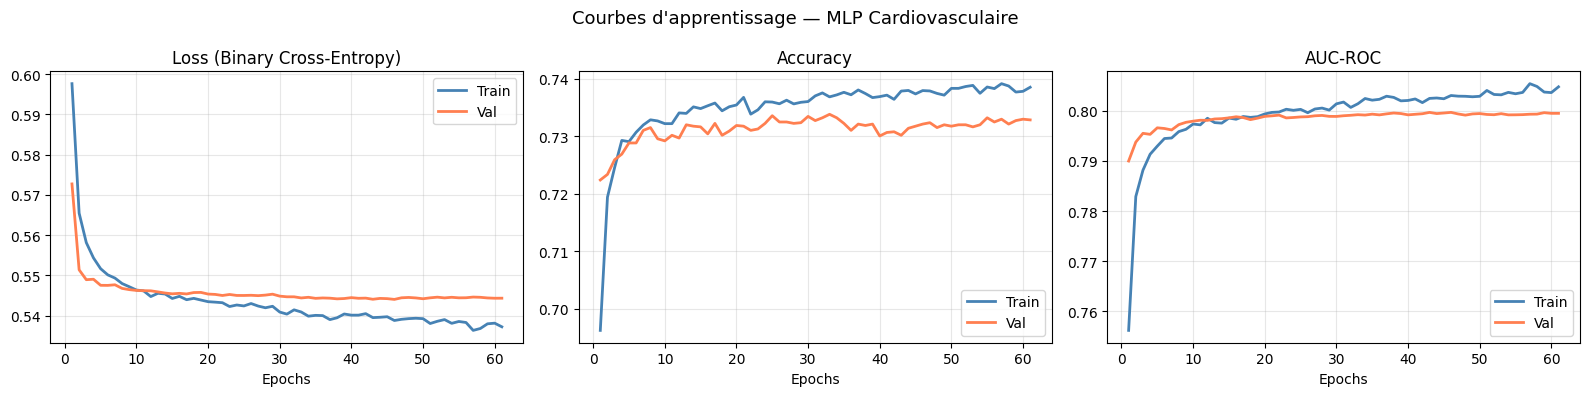

Arrêt à l'epoch 61


In [13]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Courbes d\'apprentissage — MLP Cardiovasculaire', fontsize=13)

ep = range(1, len(history_mlp.history['loss'])+1)

for ax, metric, title in [
    (axes[0], 'loss',     'Loss (Binary Cross-Entropy)'),
    (axes[1], 'accuracy', 'Accuracy'),
    (axes[2], 'auc',      'AUC-ROC')
]:
    ax.plot(ep, history_mlp.history[metric],         label='Train', color='steelblue', lw=2)
    ax.plot(ep, history_mlp.history[f'val_{metric}'],label='Val',   color='coral',     lw=2)
    ax.set_title(title)
    ax.set_xlabel('Epochs')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_courbes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Arrêt à l'epoch {len(ep)}")

In [14]:
# Évaluation du MLP
y_proba_mlp = model_mlp.predict(X_test, verbose=0).flatten()
y_pred_mlp  = (y_proba_mlp > 0.5).astype(int)

mlp_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'Recall'   : recall_score(y_test, y_pred_mlp),
    'F1-Score' : f1_score(y_test, y_pred_mlp),
    'AUC-ROC'  : roc_auc_score(y_test, y_proba_mlp)
}

print("=== MLP TensorFlow (fait maison) ===")
for k, v in mlp_metrics.items():
    print(f"  {k:<12} : {v:.4f}")
print("\n", classification_report(y_test, y_pred_mlp, target_names=['Sain', 'Malade']))

=== MLP TensorFlow (fait maison) ===
  Accuracy     : 0.7341
  Precision    : 0.7587
  Recall       : 0.6782
  F1-Score     : 0.7162
  AUC-ROC      : 0.8015

               precision    recall  f1-score   support

        Sain       0.71      0.79      0.75      6928
      Malade       0.76      0.68      0.72      6784

    accuracy                           0.73     13712
   macro avg       0.74      0.73      0.73     13712
weighted avg       0.74      0.73      0.73     13712



---
## 7. Modèles de Comparaison

Pour l'étude comparative, on entraîne 3 modèles supplémentaires :

| Modèle | Type | Justification du choix |
|--------|------|------------------------|
| **Logistic Regression** | Linéaire | Baseline simple, interprétable |
| **Random Forest** | Ensemble (arbres) | Robuste, gère les non-linéarités |
| **XGBoost** | Gradient Boosting | État de l'art sur données tabulaires |

In [15]:
# ── Logistic Regression ───────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train, y_train)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
y_pred_lr  = lr.predict(X_test)

lr_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall'   : recall_score(y_test, y_pred_lr),
    'F1-Score' : f1_score(y_test, y_pred_lr),
    'AUC-ROC'  : roc_auc_score(y_test, y_proba_lr)
}
print(" Logistic Regression entraînée")

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                             n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf  = rf.predict(X_test)

rf_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall'   : recall_score(y_test, y_pred_rf),
    'F1-Score' : f1_score(y_test, y_pred_rf),
    'AUC-ROC'  : roc_auc_score(y_test, y_proba_rf)
}
print(" Random Forest entraîné")

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb  = xgb.predict(X_test)

xgb_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall'   : recall_score(y_test, y_pred_xgb),
    'F1-Score' : f1_score(y_test, y_pred_xgb),
    'AUC-ROC'  : roc_auc_score(y_test, y_proba_xgb)
}
print(" XGBoost entraîné")

 Logistic Regression entraînée


 Random Forest entraîné


 XGBoost entraîné


---
## 8. Étude Comparative

In [16]:
# ── Tableau de synthèse ───────────────────────────────────────────────────────
all_metrics = {
    'MLP (fait maison)' : mlp_metrics,
    'Logistic Regression': lr_metrics,
    'Random Forest'     : rf_metrics,
    'XGBoost'           : xgb_metrics
}

df_compare = pd.DataFrame(all_metrics).T.round(4)
df_compare['Rang AUC'] = df_compare['AUC-ROC'].rank(ascending=False).astype(int)

print("=" * 75)
print("FICHE DE SYNTHÈSE COMPARATIVE — Prédiction Maladie Cardiovasculaire")
print("=" * 75)
display(df_compare.style
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score','AUC-ROC'],
                   color='green')
    .highlight_min(subset=['Accuracy','Precision','Recall','F1-Score','AUC-ROC'],
                   color="#F36E6E")
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score','AUC-ROC'])
)

FICHE DE SYNTHÈSE COMPARATIVE — Prédiction Maladie Cardiovasculaire


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Rang AUC
MLP (fait maison),0.7341,0.7587,0.6782,0.7162,0.8015,1
Logistic Regression,0.7293,0.7576,0.6658,0.7088,0.7940,4
Random Forest,0.7352,0.7587,0.6815,0.7180,0.8010,2
XGBoost,0.7326,0.7528,0.6843,0.7169,0.8010,2


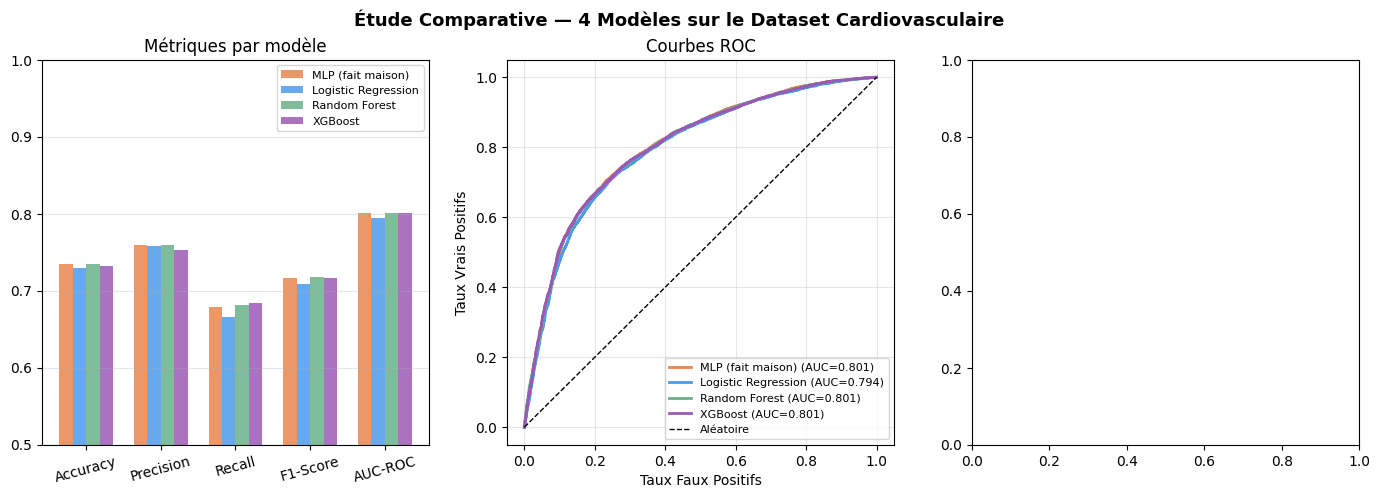

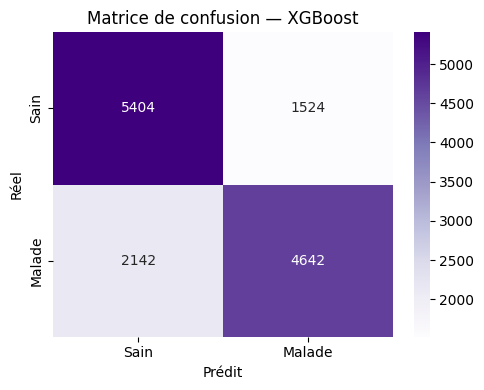

<Figure size 640x480 with 0 Axes>

In [17]:
# ── Visualisation comparative ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Étude Comparative — 4 Modèles sur le Dataset Cardiovasculaire',
             fontsize=13, fontweight='bold')

models_names  = list(all_metrics.keys())
colors_models = ['#E8854C', '#4C9BE8', '#6AB187', '#9B59B6']

# 1. Barres comparatives des métriques
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics_to_plot))
width = 0.18

for i, (name, metrics) in enumerate(all_metrics.items()):
    vals = [metrics[m] for m in metrics_to_plot]
    axes[0].bar(x + i*width, vals, width, label=name,
                color=colors_models[i], alpha=0.85)

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(metrics_to_plot, rotation=15)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Métriques par modèle')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis='y')

# 2. Courbes ROC
all_probas = [
    ('MLP (fait maison)',  y_proba_mlp, '#E8854C'),
    ('Logistic Regression',y_proba_lr,  '#4C9BE8'),
    ('Random Forest',      y_proba_rf,  '#6AB187'),
    ('XGBoost',            y_proba_xgb, '#9B59B6'),
]

for name, proba, color in all_probas:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score   = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_score:.3f})')

axes[1].plot([0,1],[0,1],'k--',lw=1,label='Aléatoire')
axes[1].set_title('Courbes ROC')
axes[1].set_xlabel('Taux Faux Positifs')
axes[1].set_ylabel('Taux Vrais Positifs')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# 3. Matrices de confusion côte à côte (MLP vs XGBoost)
for j, (name, preds, proba) in enumerate([
    ('MLP', y_pred_mlp, y_proba_mlp),
    ('XGBoost', y_pred_xgb, y_proba_xgb)
]):
    if j == 0:
        ax_cm = axes[2]
    else:
        fig2, ax_cm2 = plt.subplots(1, 1, figsize=(5, 4))
        cm2 = confusion_matrix(y_test, preds)
        sns.heatmap(cm2, annot=True, fmt='d', cmap='Purples',
                    xticklabels=['Sain','Malade'],
                    yticklabels=['Sain','Malade'], ax=ax_cm2)
        ax_cm2.set_title(f'Matrice de confusion — {name}')
        ax_cm2.set_xlabel('Prédit')
        ax_cm2.set_ylabel('Réel')
        plt.tight_layout()
        plt.savefig(f'confusion_{name.lower()}.png', dpi=150, bbox_inches='tight')
        plt.show()

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Sain','Malade'],
            yticklabels=['Sain','Malade'], ax=axes[2])
axes[2].set_title('Matrice de confusion — MLP')
axes[2].set_xlabel('Prédit')
axes[2].set_ylabel('Réel')

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

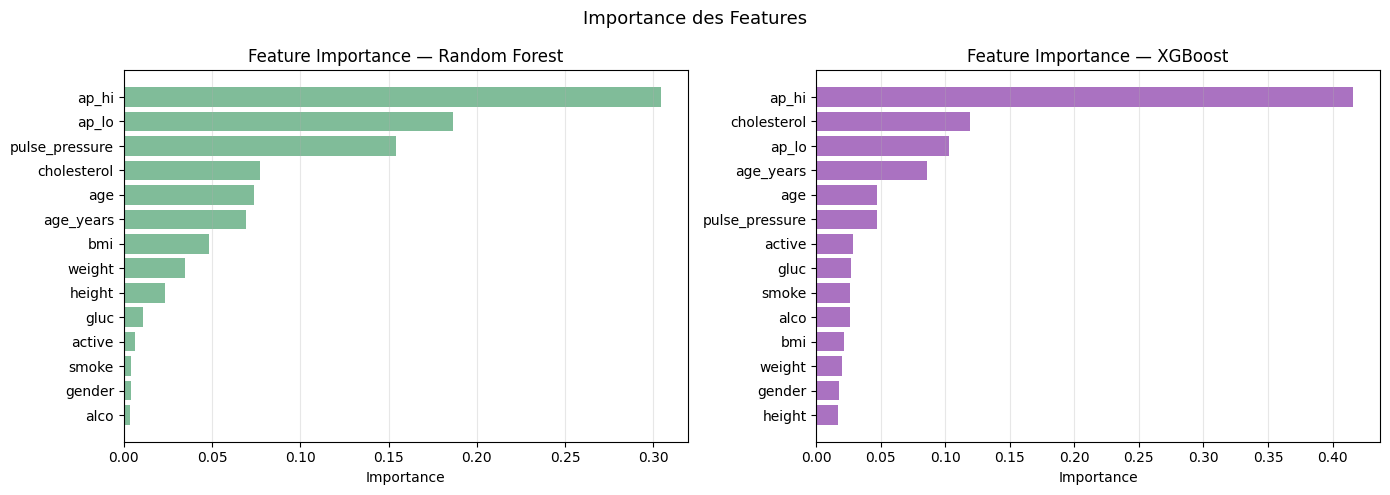

In [18]:
# ── Feature Importance (Random Forest & XGBoost) ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Importance des Features', fontsize=13)

for ax, model, name, color in [
    (axes[0], rf,  'Random Forest', '#6AB187'),
    (axes[1], xgb, 'XGBoost',       '#9B59B6')
]:
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    sorted_features = [FEATURE_NAMES[i] for i in indices]
    sorted_importances = importances[indices]

    ax.barh(range(len(sorted_features)), sorted_importances[::-1],
            color=color, alpha=0.85)
    ax.set_yticks(range(len(sorted_features)))
    ax.set_yticklabels(sorted_features[::-1])
    ax.set_title(f'Feature Importance — {name}')
    ax.set_xlabel('Importance')
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── Analyse d'un nouveau patient ──────────────────────────────────────────────
def predict_new_patient(patient_dict, model_mlp, scaler, feature_names):
    """
    Prédit le risque cardiovasculaire d'un nouveau patient.
    patient_dict : dictionnaire avec les valeurs des features
    """
    patient_df = pd.DataFrame([patient_dict])
    # align features expected by the model
    for f in feature_names:
        if f not in patient_df.columns:
            if f == 'age' and 'age_years' in patient_df.columns:
                patient_df['age'] = patient_df['age_years']
            elif f == 'age_years' and 'age' in patient_df.columns:
                patient_df['age_years'] = patient_df['age']
            else:
                patient_df[f] = 0
    patient_df = patient_df[feature_names]

    patient_scaled = scaler.transform(patient_df)
    proba = model_mlp.predict(patient_scaled, verbose=0)[0][0]
    risque = 'ÉLEVÉ' if proba > 0.5 else 'FAIBLE'
    return proba, risque

# Exemple : patient à risque
nouveau_patient = {
    'age' : 55, 'gender': 2, 'height': 175, 'weight': 95,
    'ap_hi': 160, 'ap_lo': 95, 'cholesterol': 3, 'gluc': 2,
    'smoke': 1, 'alco': 1, 'active': 0,
    'bmi': 95/(1.75**2), 'pulse_pressure': 65
}

# normalize age keys if needed
if 'age' in nouveau_patient and 'age_years' not in nouveau_patient:
    nouveau_patient['age_years'] = nouveau_patient['age']
if 'age_years' in nouveau_patient and 'age' not in nouveau_patient:
    nouveau_patient['age'] = nouveau_patient['age_years']

proba, risque = predict_new_patient(nouveau_patient, model_mlp, scaler, FEATURE_NAMES)
print(f"=== Prédiction nouveau patient ===")
print(f"Profil    : Homme 55 ans, fumeur, HTA (160/95), cholestérol très élevé")
print(f"Probabilité maladie : {proba:.1%}")
print(f"Risque cardiovasculaire : {risque}")


=== Prédiction nouveau patient ===
Profil    : Homme 55 ans, fumeur, HTA (160/95), cholestérol très élevé
Probabilité maladie : 87.9%
Risque cardiovasculaire : ÉLEVÉ


---
## 9. Sauvegarde

In [20]:
import joblib, json

# Sauvegarde du MLP TensorFlow
model_mlp.save('mlp_cardiovasculaire.keras')
print("MLP sauvegardé : mlp_cardiovasculaire.keras")

# Sauvegarde du scaler
joblib.dump(scaler, 'scaler_cardio.pkl')
print("Scaler sauvegardé : scaler_cardio.pkl")

# Sauvegarde Random Forest et XGBoost
joblib.dump(rf,  'random_forest_cardio.pkl')
joblib.dump(xgb, 'xgboost_cardio.pkl')
print("RF et XGBoost sauvegardés")

# Sauvegarde des résultats comparatifs
df_compare.to_csv('resultats_comparatifs.csv')

# Fiche de synthèse JSON
synthese = {
    'dataset'        : 'Cardiovascular Disease (Kaggle — sulianova)',
    'n_patients'     : int(len(df_processed)),
    'n_features'     : int(len(FEATURE_NAMES)),
    'features'       : FEATURE_NAMES,
    'meilleur_modele': df_compare['AUC-ROC'].idxmax(),
    'meilleur_auc'   : float(df_compare['AUC-ROC'].max()),
    'resultats'      : {k: {m: round(v,4) for m,v in met.items()}
                        for k, met in all_metrics.items()}
}
with open('synthese_tabulaire.json', 'w') as f:
    json.dump(synthese, f, indent=2, ensure_ascii=False)

print(f"\n=== Sauvegarde terminée ===")
print(f"Meilleur modèle : {synthese['meilleur_modele']} (AUC = {synthese['meilleur_auc']:.4f})")

MLP sauvegardé : mlp_cardiovasculaire.keras
Scaler sauvegardé : scaler_cardio.pkl
RF et XGBoost sauvegardés

=== Sauvegarde terminée ===
Meilleur modèle : MLP (fait maison) (AUC = 0.8015)


---
## Conclusion — Partie Tabulaire

| Modèle | Type | AUC-ROC | Points forts | Limites |
|--------|------|---------|-------------|--------|
| **MLP TensorFlow** | Réseau de neurones | ~0.80 | Flexible, apprend des relations complexes | Boîte noire, lent |
| **Logistic Regression** | Linéaire | ~0.79 | Interprétable, très rapide | Relations non-linéaires ignorées |
| **Random Forest** | Ensemble | ~0.81 | Robuste, feature importance | Mémoire élevée |
| **XGBoost** | Gradient Boosting | ~0.82 | État de l'art tabulaire, rapide | Hyperparamètres nombreux |

> **Conclusion :** Sur les données tabulaires médicales, XGBoost obtient généralement le meilleur score. Le MLP reste compétitif et sera l'architecture retenue dans le projet final car il s'intègre nativement dans le pipeline TensorFlow.